Setup & installs

In [ ]:
!pip install medmnist -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.6 MB/s eta 0:00:00


Download dataset

In [ ]:
import medmnist
from medmnist import PneumoniaMNIST

train_dataset = PneumoniaMNIST(split='train', download=True, size=224)
val_dataset = PneumoniaMNIST(split='val', download=True, size=224)
test_dataset = PneumoniaMNIST(split='test', download=True, size=224)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Classes: {train_dataset.info['label']}")

100%|██████████| 214M/214M [02:39<00:00, 1.35MB/s]


Train: 4708 | Val: 524 | Test: 624
Classes: {'0': 'normal', '1': 'pneumonia'}


Dataloaders with transforms

In [ ]:
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T

transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

train_dataset.transform = transform
val_dataset.transform = transform
test_dataset.transform = transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

Model (ResNet18 transfer learning, adapted for grayscale)

In [ ]:
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights='IMAGENET1K_V1')

# Adapt first conv layer for single-channel (grayscale) input
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Replace final layer for binary classification
model.fc = nn.Linear(model.fc.in_features, 1)

model = model.to(device)
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 124MB/s]


Linear(in_features=512, out_features=1, bias=True)


Training loop (with train & val loss/accuracy)

In [ ]:
import time

EPOCHS = 20
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

for epoch in range(EPOCHS):
    # ---- Training ----
    model.train()
    epoch_loss, correct, total = 0, 0, 0
    start = time.time()

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = loss_fn(outputs, labels.squeeze(1))
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels.squeeze(1)).sum().item()
        total += labels.size(0)

    train_losses.append(epoch_loss / len(train_loader))
    train_accs.append(correct / total)

    # ---- Validation ----
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().to(device)

            outputs = model(images).squeeze(1)
            loss = loss_fn(outputs, labels.squeeze(1))

            val_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (preds == labels.squeeze(1)).sum().item()
            val_total += labels.size(0)

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(val_correct / val_total)

    if val_accs[-1] > best_val_acc:
        best_val_acc = val_accs[-1]
        torch.save(model.state_dict(), "best_pneumonia_resnet18.pth")

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_losses[-1]:.4f} Acc: {train_accs[-1]:.4f} | "
          f"Val Loss: {val_losses[-1]:.4f} Acc: {val_accs[-1]:.4f} | Time: {time.time()-start:.1f}s")

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

Epoch 1/20 | Train Loss: 0.1295 Acc: 0.9497 | Val Loss: 0.0517 Acc: 0.9790 | Time: 15.7s
Epoch 2/20 | Train Loss: 0.0521 Acc: 0.9824 | Val Loss: 0.0550 Acc: 0.9752 | Time: 14.4s
Epoch 3/20 | Train Loss: 0.0461 Acc: 0.9849 | Val Loss: 0.1640 Acc: 0.9408 | Time: 14.4s
Epoch 4/20 | Train Loss: 0.0212 Acc: 0.9932 | Val Loss: 0.0762 Acc: 0.9771 | Time: 14.6s
Epoch 5/20 | Train Loss: 0.0404 Acc: 0.9864 | Val Loss: 0.0434 Acc: 0.9828 | Time: 15.0s
Epoch 6/20 | Train Loss: 0.0093 Acc: 0.9979 | Val Loss: 0.0427 Acc: 0.9847 | Time: 15.3s
Epoch 7/20 | Train Loss: 0.0081 Acc: 0.9989 | Val Loss: 0.0902 Acc: 0.9676 | Time: 15.9s
Epoch 8/20 | Train Loss: 0.0359 Acc: 0.9887 | Val Loss: 0.0442 Acc: 0.9828 | Time: 16.3s
Epoch 9/20 | Train Loss: 0.0163 Acc: 0.9955 | Val Loss: 0.0517 Acc: 0.9828 | Time: 17.1s
Epoch 10/20 | Train Loss: 0.0031 Acc: 0.9996 | Val Loss: 0.0558 Acc: 0.9771 | Time: 18.2s
Epoch 11/20 | Train Loss: 0.0039 Acc: 0.9996 | Val Loss: 0.0488 Acc: 0.9790 | Time: 17.4s
Epoch 12/20 | Train

Plot training curves

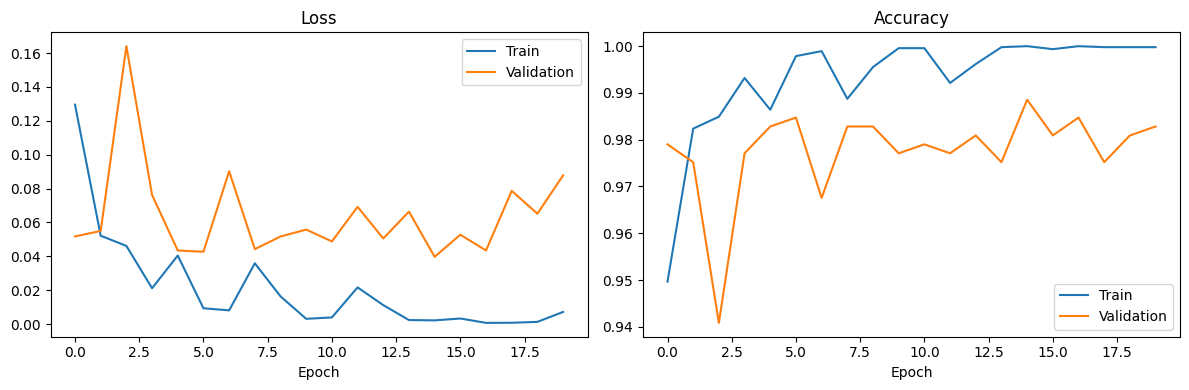

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(train_losses, label="Train")
ax[0].plot(val_losses, label="Validation")
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(train_accs, label="Train")
ax[1].plot(val_accs, label="Validation")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].legend()

plt.tight_layout()
plt.savefig("classification_training_curves.png", dpi=150)
plt.show()

Evaluate on test set (accuracy, precision, recall, F1, confusion matrix)

Test Accuracy:  0.8958
Precision:      0.8587
Recall:         0.9974
F1 Score:       0.9229


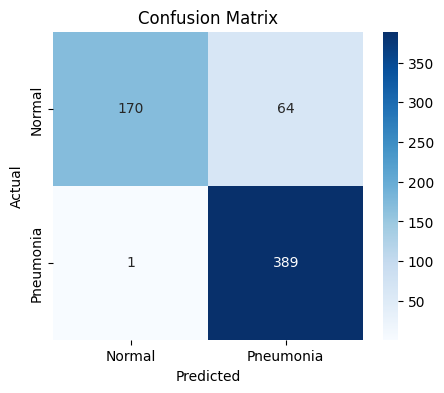

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import seaborn as sns

model.load_state_dict(torch.load("best_pneumonia_resnet18.pth"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        preds = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.squeeze(1).numpy())

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"Test Accuracy:  {acc:.4f}")
print(f"Precision:      {prec:.4f}")
print(f"Recall:         {rec:.4f}")
print(f"F1 Score:       {f1:.4f}")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

Visualize sample predictions

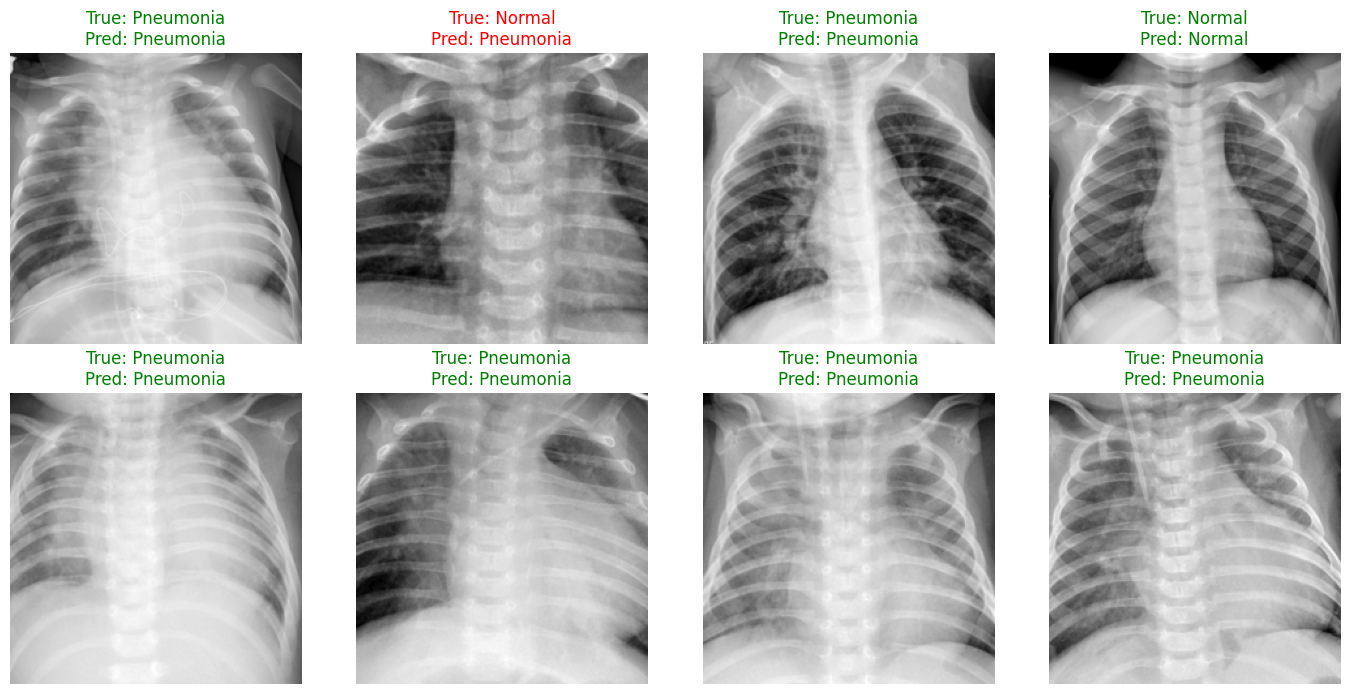

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
class_names = ['Normal', 'Pneumonia']

with torch.no_grad():
    for i in range(8):
        image, label = test_dataset[i]
        pred = torch.sigmoid(model(image.unsqueeze(0).to(device))).item()
        pred_label = 1 if pred > 0.5 else 0

        ax = axes[i // 4, i % 4]
        ax.imshow(image.squeeze(), cmap='gray')
        color = 'green' if pred_label == label.item() else 'red'
        ax.set_title(f"True: {class_names[int(label.item())]}\nPred: {class_names[pred_label]}", color=color)
        ax.axis('off')

plt.tight_layout()
plt.savefig("classification_predictions.png", dpi=150)
plt.show()

Download bundle

In [ ]:
from google.colab import files
import shutil, os

os.makedirs('/content/classification_bundle', exist_ok=True)
shutil.copy('/content/classification_training_curves.png', '/content/classification_bundle/')
shutil.copy('/content/confusion_matrix.png', '/content/classification_bundle/')
shutil.copy('/content/classification_predictions.png', '/content/classification_bundle/')
shutil.copy('/content/best_pneumonia_resnet18.pth', '/content/classification_bundle/')

shutil.make_archive('/content/classification_bundle', 'zip', '/content/classification_bundle')
files.download('/content/classification_bundle.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>